# D2 — Maze-Solving Robot: Data Exploration

## 1. Introduction

This project focuses on a simulated maze-solving robot navigating through a grid-based maze from a start position to a goal position.

The project evaluates different search algorithms, including BFS, DFS, A*, Reactive A*, and D* Lite. The experiments will study their performance using measures such as path length, nodes expanded, execution time, memory usage, and replanning count.

For this exploration, mazes are generated programmatically with different sizes and configurations. The generated maze data will be analyzed to understand its structure and characteristics before evaluating the search algorithms.

## 2. Import Libraries

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Add the src folder to Python's import path.
project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from maze_generator import generate_maze

## 3. Generate Maze Dataset

In [4]:
# Generate a sample 10 x 10 maze.

maze = generate_maze(
    rows=10,
    cols=10,
    seed=42
)

print("Maze size:", maze.rows, "x", maze.cols)
print("Start:", maze.start)
print("Goal:", maze.goal)

Maze size: 10 x 10
Start: (0, 0)
Goal: (9, 9)


## 4. Maze Dataset Overview

In [5]:
# Basic information about the generated maze.

print("Number of rows:", maze.rows)
print("Number of columns:", maze.cols)
print("Total cells:", maze.rows * maze.cols)

print("Start position:", maze.start)
print("Goal position:", maze.goal)

print("Total wall records:", len(maze.walls))

Number of rows: 10
Number of columns: 10
Total cells: 100
Start position: (0, 0)
Goal position: (9, 9)
Total wall records: 100


In [10]:
# Explore different maze sizes.

maze_sizes = [5, 10, 20, 30]

for size in maze_sizes:
    test_maze = generate_maze(
        rows=size,
        cols=size,
        seed=42
    )

    print(
        f"{size} x {size} maze -> "
        f"{test_maze.rows * test_maze.cols} cells"
    )

5 x 5 maze -> 25 cells
10 x 10 maze -> 100 cells
20 x 20 maze -> 400 cells
30 x 30 maze -> 900 cells


Displaying 5 x 5 maze


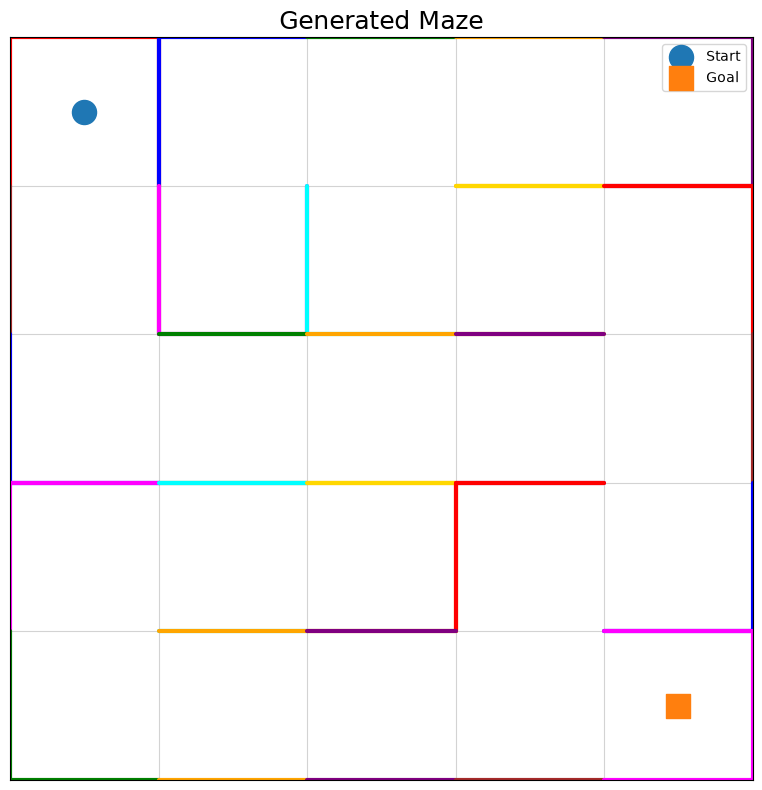

Displaying 10 x 10 maze


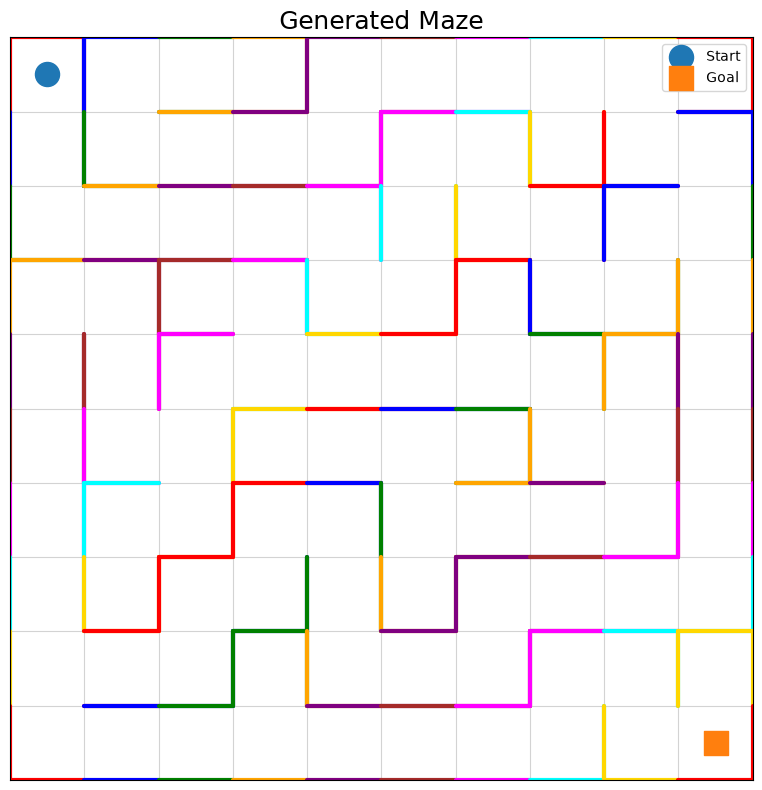

Displaying 20 x 20 maze


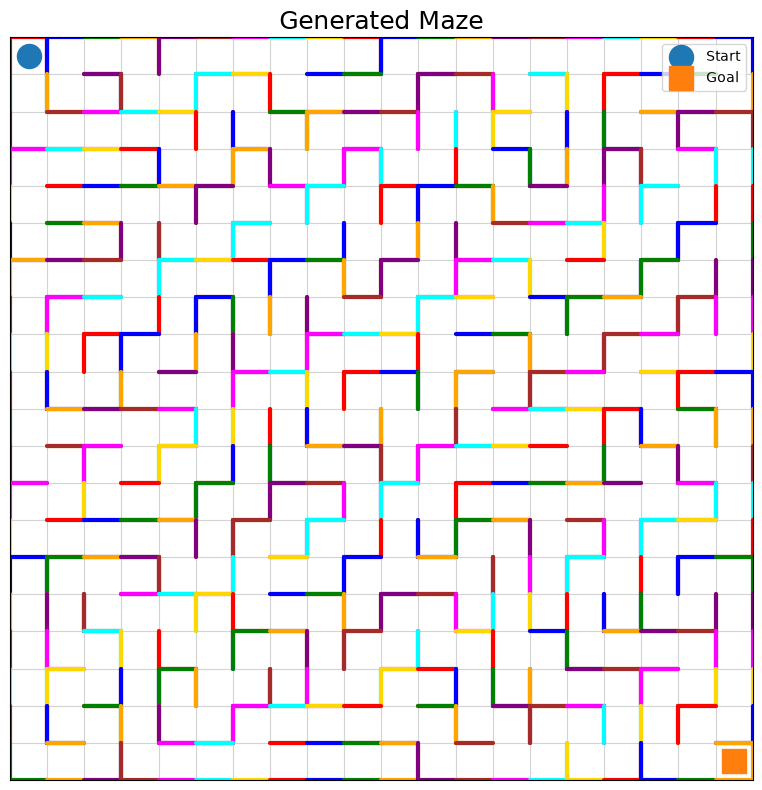

Displaying 30 x 30 maze


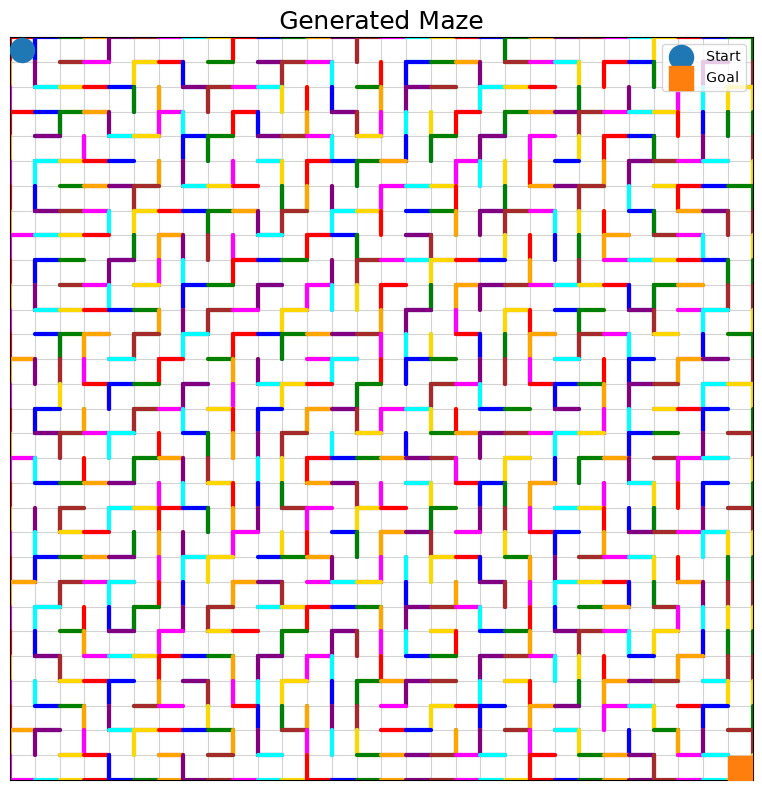

In [11]:
# Visualize the different maze sizes.

for size in maze_sizes:
    test_maze = generate_maze(
        rows=size,
        cols=size,
        seed=42
    )

    print(f"Displaying {size} x {size} maze")

    # Draw the maze.
    from maze_visualizer import display_maze
    display_maze(test_maze)

In [12]:
# Create a simple comparison of the maze sizes.

print("Maze Size Comparison")
print("-" * 40)

for size in maze_sizes:
    total_cells = size * size

    print(
        f"{size} x {size} maze | "
        f"Total cells: {total_cells}"
    )

Maze Size Comparison
----------------------------------------
5 x 5 maze | Total cells: 25
10 x 10 maze | Total cells: 100
20 x 20 maze | Total cells: 400
30 x 30 maze | Total cells: 900


In [13]:
# Check whether any basic maze information is missing.

maze_information = {
    "rows": maze.rows,
    "columns": maze.cols,
    "start": maze.start,
    "goal": maze.goal,
    "walls": maze.walls
}

for name, value in maze_information.items():
    print(f"{name}: {'Missing' if value is None else 'Present'}")

rows: Present
columns: Present
start: Present
goal: Present
walls: Present


## 5. Maze Properties

In [6]:
# Calculate basic structural properties of the maze.

total_cells = maze.rows * maze.cols

wall_count = 0

for cell in maze.walls:
    for direction in maze.walls[cell]:
        if maze.walls[cell][direction]:
            wall_count += 1

print("Total cells:", total_cells)
print("Total wall entries:", wall_count)
print("Average wall entries per cell:", wall_count / total_cells)

Total cells: 100
Total wall entries: 202
Average wall entries per cell: 2.02


In [14]:
# Check the number of available movements from each cell.

neighbor_counts = []

for row in range(maze.rows):
    for col in range(maze.cols):
        cell = (row, col)
        neighbor_counts.append(len(maze.get_neighbors(cell)))

print("Minimum neighbors:", min(neighbor_counts))
print("Maximum neighbors:", max(neighbor_counts))
print("Average neighbors:", sum(neighbor_counts) / len(neighbor_counts))

Minimum neighbors: 1
Maximum neighbors: 3
Average neighbors: 1.98


## 6. Data Types

In [7]:
# Check the data types used in the maze representation.

print("Type of maze:", type(maze))
print("Type of maze.rows:", type(maze.rows))
print("Type of maze.cols:", type(maze.cols))
print("Type of start:", type(maze.start))
print("Type of goal:", type(maze.goal))
print("Type of walls:", type(maze.walls))

Type of maze: <class 'maze.Maze'>
Type of maze.rows: <class 'int'>
Type of maze.cols: <class 'int'>
Type of start: <class 'tuple'>
Type of goal: <class 'tuple'>
Type of walls: <class 'dict'>


## 7. Basic Statistics

In [8]:
# Calculate basic statistics about the maze.

print("Maze dimensions:", maze.rows, "x", maze.cols)
print("Total cells:", maze.rows * maze.cols)

print("Start row:", maze.start[0])
print("Start column:", maze.start[1])

print("Goal row:", maze.goal[0])
print("Goal column:", maze.goal[1])

print("Manhattan distance from start to goal:",
      abs(maze.start[0] - maze.goal[0]) +
      abs(maze.start[1] - maze.goal[1]))

Maze dimensions: 10 x 10
Total cells: 100
Start row: 0
Start column: 0
Goal row: 9
Goal column: 9
Manhattan distance from start to goal: 18


## 8. Initial Observations



- The generated maze contains 100 cells for a 10 × 10 configuration.
- The start position is located at the top-left cell, while the goal is located at the bottom-right cell.
- Each cell has four possible wall directions: up, right, down, and left.
- The maze generator creates passages by removing walls between neighboring cells.
- The Manhattan distance between the start and goal is 18, but the actual path through the maze can be longer because the robot must follow the available passages.
- In the 10 × 10 generated maze, each cell has between 1 and 3 reachable neighbors, with an average of 1.98. This indicates that the maze contains both dead-end cells and cells with multiple possible movement directions.

## 9. Published Paper Result Reproduction

### Selected Paper

Paper: "Efficient Pathfinding in a Maze to overcome Challenges in Robotics and AI Using Breadth-First Search"

Conference: 2025 IEEE 14th International Conference on Communication Systems and Network Technologies

DOI: 10.1109/CSNT64827.2025.10968383

### What the Paper Studied

The paper studies Breadth-First Search (BFS) for pathfinding in a maze. BFS explores the maze using a queue and searches level by level to find a route from the starting position to the target position , which gives a optimal solution.

### Why We Selected This Paper

This paper is closely related to our project because our system also uses a simulated grid-based maze and BFS for pathfinding. Our maze uses four-direction movement and has a defined start and goal position.and have simulated dataset.

### What We Will Reproduce

We will reproduce the BFS maze-pathfinding approach described in the paper along with DFS, A*, D* lite using our own generated maze environments.

The experiment will investigate whether BFS can successfully find a path from the start cell or some other algorithm gove better path to the goal cell and how its search effort changes as the maze size increases.

### Experimental Setup

- Environment: Simulated grid-based mazes
- Maze sizes: 5 × 5, 10 × 10, 20 × 20, and 30 × 30
- Start position: Top-left cell
- Goal position: Bottom-right cell
- Movement: Up, down, left, and right
- Algorithm: Breadth-First Search (BFS)
- Maze generation: Programmatically generated mazes
- Main metrics: Path length and nodes expanded
- Random seed: Fixed seed for reproducibility

### Reproduction Procedure

1. Generate a maze of a selected size.
2. Set the start and goal positions.
3. Run BFS on the generated maze.
4. Record whether BFS successfully reaches the goal.
5. Record the path length.
6. Record the number of nodes expanded.
7. Repeat the experiment for different maze sizes.
8. Compare the observed BFS behavior with the approach described in the selected paper.

### Expected Observation

BFS should be able to find a path when the goal is reachable and give optimal solution. Since BFS explores the search space level by level, it should find a shortest path when all movements have equal cost.

As the maze size increases, the number of cells that may need to be explored is expected to increase.

In [15]:
# Run BFS on different maze sizes.

from bfs import bfs

bfs_results = []

for size in maze_sizes:
    test_maze = generate_maze(
        rows=size,
        cols=size,
        seed=42
    )

    result = bfs(test_maze)

    bfs_results.append({
        "maze_size": f"{size}x{size}",
        "success": result["success"],
        "path_length": result["path_length"],
        "nodes_expanded": result["nodes_expanded"]
    })

    print(
        f"{size}x{size} | "
        f"Success: {result['success']} | "
        f"Path length: {result['path_length']} | "
        f"Nodes expanded: {result['nodes_expanded']}"
    )

5x5 | Success: True | Path length: 10 | Nodes expanded: 15
10x10 | Success: True | Path length: 48 | Nodes expanded: 82
20x20 | Success: True | Path length: 210 | Nodes expanded: 373
30x30 | Success: True | Path length: 436 | Nodes expanded: 743


### Reproduction Results

The BFS algorithm successfully found a path for all four tested maze sizes.

| Maze Size | Success | Path Length | Nodes Expanded |
|-----------|---------|-------------|----------------|
| 5 × 5 | True | 10 | 15 |
| 10 × 10 | True | 48 | 82 |
| 20 × 20 | True | 210 | 373 |
| 30 × 30 | True | 436 | 743 |

The results show that BFS successfully solves all tested mazes. As the maze size increases, both the path length and the number of nodes expanded increase. This indicates that the search effort grows as the size of the maze increases.

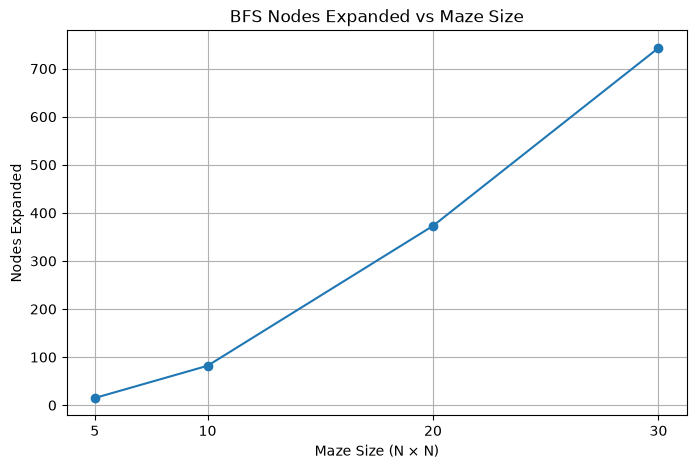

In [17]:
# Visualize BFS search effort as maze size increases.

sizes = [5, 10, 20, 30]
nodes_expanded = [15, 82, 373, 743]

plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    nodes_expanded,
    marker="o"
)

plt.xlabel("Maze Size (N × N)")
plt.ylabel("Nodes Expanded")
plt.title("BFS Nodes Expanded vs Maze Size")
plt.xticks(sizes)

plt.grid(True)
plt.show()